# Human Activity Recognition (HAR) Classification

This notebook presents a complete machine learning pipeline for classifying human activities
using accelerometer and gyroscope data. The dataset contains six activity classes:
Walking, Jogging, Upstairs, Downstairs, Sitting, and Standing.

**Sections:**
1. Data Processing
2. Imbalance Analysis and Mitigation
3. Model Comparison and Hyperparameter Tuning
4. Results Discussion
5. Lessons Learned

## Setup: Import Libraries

We import all necessary libraries for data manipulation, visualization, modeling,
imbalanced learning, and hyperparameter optimization.

In [3]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
import os

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset loading
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# Imbalanced learning
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

# Hyperparameter optimization
import optuna
from optuna.pruners import MedianPruner

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Data paths
RAW_DATA_DIR = 'data/raw'
PROCESSED_DATA_DIR = 'data/processed'
os.makedirs(RAW_DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('All libraries imported successfully.')

All libraries imported successfully.


---
# Section 1: Data Processing

In this section we load the Human Activity Recognition dataset, explore its structure,
handle missing values, encode labels, scale features, and split into train/test sets.

### 1.1 Load the Dataset

We load the dataset using `kagglehub` from the Kaggle repository
`die9origephit/human-activity-recognition`. The raw CSV is saved to `data/raw/`
for reproducibility.

In [4]:
# Load dataset from Kaggle
file_path = "time_series_data_human_activities.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "die9origephit/human-activity-recognition",
    file_path
)

# Save raw data to data/raw/
df.to_csv(os.path.join(RAW_DATA_DIR, file_path), index=False)
print(f'Raw dataset saved to {RAW_DATA_DIR}/{file_path}')

print(f'Dataset shape: {df.shape}')
df.head()

Raw dataset saved to data/raw/time_series_data_human_activities.csv
Dataset shape: (1073623, 6)


,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95


### 1.2 Initial Exploration

Let's inspect the first rows, data types, and the distribution of the target variable
to understand the structure of our data.

In [5]:
# Display first rows
print('=== First 5 Rows ===')
display(df.head())

# Data types
print('\n=== Data Types ===')
print(df.dtypes)

# Shape
print(f'\nRows: {df.shape[0]}, Columns: {df.shape[1]}')

# Identify target column (first object/string column, typically 'activity')
target_col = df.select_dtypes(include='object').columns[0]
print(f'\nTarget column: "{target_col}"')

# Target variable distribution
print('\n=== Target Variable Distribution ===')
print(df[target_col].value_counts())
print(f'\nPercentages:')
print(df[target_col].value_counts(normalize=True).mul(100).round(2))

=== First 5 Rows ===


,user,activity,timestamp,x-axis,y-axis,z-axis
0,1,Walking,4991922345000,0.69,10.80,-2.03
1,1,Walking,4991972333000,6.85,7.44,-0.50
2,1,Walking,4992022351000,0.93,5.63,-0.50
3,1,Walking,4992072339000,-2.11,5.01,-0.69
4,1,Walking,4992122358000,-4.59,4.29,-1.95



=== Data Types ===
user           int64
activity      object
timestamp      int64
x-axis       float64
y-axis       float64
z-axis       float64
dtype: object

Rows: 1073623, Columns: 6

Target column: "activity"

=== Target Variable Distribution ===
activity
Walking       417901
Jogging       324600
Upstairs      122598
Downstairs    100192
Sitting        59939
Standing       48393
Name: count, dtype: int64

Percentages:
activity
Walking       38.92
Jogging       30.23
Upstairs      11.42
Downstairs     9.33
Sitting        5.58
Standing       4.51
Name: proportion, dtype: float64


### 1.3 Check and Handle Missing Values

We check for missing values across all columns. If any are found, we apply
`SimpleImputer` with the median strategy (robust to outliers in sensor data).

In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage (%)': missing_pct})
print('=== Missing Values ===')
display(missing_df[missing_df['Missing Count'] > 0])

total_missing = missing.sum()
print(f'\nTotal missing values: {total_missing}')

# Separate features and target
X = df.drop(columns=[target_col])
y = df[target_col].copy()

# Apply SimpleImputer if needed
if total_missing > 0:
    print('\nApplying SimpleImputer (median strategy)...')
    imputer = SimpleImputer(strategy='median')
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
    print('Missing values imputed successfully.')
else:
    print('\nNo missing values found. No imputation needed.')

print(f'\nFeature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')

=== Missing Values ===


,Missing Count,Percentage (%)



Total missing values: 0

No missing values found. No imputation needed.

Feature matrix shape: (1073623, 5)
Target vector shape: (1073623,)


### 1.4 Encode the Target Variable

We use `LabelEncoder` to convert the string activity labels into integer codes
required by scikit-learn classifiers.

In [7]:
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Show mapping
class_names = label_encoder.classes_
print('Label Encoding Mapping:')
for idx, name in enumerate(class_names):
    print(f'  {name} -> {idx}')

print(f'\nNumber of classes: {len(class_names)}')

Label Encoding Mapping:
  Downstairs -> 0
  Jogging -> 1
  Sitting -> 2
  Standing -> 3
  Upstairs -> 4
  Walking -> 5

Number of classes: 6


### 1.5 Feature Scaling with StandardScaler

We apply `StandardScaler` (zero mean, unit variance) to all features. This is the
appropriate choice because:

- **Accelerometer and gyroscope signals** can have very different scales and ranges.
- **Distance-based models** (KNN, SVC) are sensitive to feature magnitudes.
- **Gradient-based optimization** (Logistic Regression, Gradient Boosting) converges
  faster with standardized features.
- Unlike MinMaxScaler, StandardScaler is less affected by outliers in sensor data.

In [8]:
# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Feature scaling applied (StandardScaler).')
print('\n=== Scaled Feature Statistics ===')
display(X_scaled.describe().round(4))

Feature scaling applied (StandardScaler).

=== Scaled Feature Statistics ===


,user,timestamp,x-axis,y-axis,z-axis
count,1.073623e+06,1.073623e+06,1.073623e+06,1.073623e+06,1.073623e+06
mean,-0.000000e+00,-0.000000e+00,0.000000e+00,-0.000000e+00,0.000000e+00
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-1.731000e+00,-6.684000e-01,-2.932300e+00,-4.001600e+00,-4.218200e+00
25%,-8.561000e-01,-6.280000e-01,-5.251000e-01,-5.930000e-01,-5.561000e-01
50%,1.880000e-02,-4.713000e-01,-4.800000e-02,1.006000e-01,-9.240000e-02
75%,8.937000e-01,4.810000e-02,5.563000e-01,6.338000e-01,4.923000e-01
max,1.671300e+00,3.595000e+00,2.787100e+00,1.887300e+00,4.010500e+00


### 1.6 Stratified Train/Test Split (80/20)

We use a stratified split to ensure that the class proportions are preserved
in both training and test sets. This is especially important given the class imbalance.

In [9]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size:     {X_test.shape[0]} samples')

# Show class distribution before and after split
print('\n=== Class Distribution (Full Dataset) ===')
full_dist = pd.Series(y_encoded).value_counts().sort_index()
for idx, count in full_dist.items():
    pct = count / len(y_encoded) * 100
    print(f'  {class_names[idx]:12s}: {count:5d} ({pct:.1f}%)')

print('\n=== Class Distribution (Training Set) ===')
train_dist = pd.Series(y_train).value_counts().sort_index()
for idx, count in train_dist.items():
    pct = count / len(y_train) * 100
    print(f'  {class_names[idx]:12s}: {count:5d} ({pct:.1f}%)')

print('\n=== Class Distribution (Test Set) ===')
test_dist = pd.Series(y_test).value_counts().sort_index()
for idx, count in test_dist.items():
    pct = count / len(y_test) * 100
    print(f'  {class_names[idx]:12s}: {count:5d} ({pct:.1f}%)')

# Save processed data to data/processed/
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)
X_train_df['target'] = y_train
X_test_df['target'] = y_test

X_train_df.to_csv(os.path.join(PROCESSED_DATA_DIR, 'train.csv'), index=False)
X_test_df.to_csv(os.path.join(PROCESSED_DATA_DIR, 'test.csv'), index=False)

# Save label mapping
label_map = pd.DataFrame({'label': class_names, 'encoded': range(len(class_names))})
label_map.to_csv(os.path.join(PROCESSED_DATA_DIR, 'label_mapping.csv'), index=False)

print(f'\nProcessed data saved to {PROCESSED_DATA_DIR}/')
print(f'  - train.csv ({X_train_df.shape[0]} rows)')
print(f'  - test.csv ({X_test_df.shape[0]} rows)')
print(f'  - label_mapping.csv')

Training set size: 858898 samples
Test set size:     214725 samples

=== Class Distribution (Full Dataset) ===
  Downstairs  : 100192 (9.3%)
  Jogging     : 324600 (30.2%)
  Sitting     : 59939 (5.6%)
  Standing    : 48393 (4.5%)
  Upstairs    : 122598 (11.4%)
  Walking     : 417901 (38.9%)

=== Class Distribution (Training Set) ===
  Downstairs  : 80154 (9.3%)
  Jogging     : 259680 (30.2%)
  Sitting     : 47951 (5.6%)
  Standing    : 38714 (4.5%)
  Upstairs    : 98078 (11.4%)
  Walking     : 334321 (38.9%)

=== Class Distribution (Test Set) ===
  Downstairs  : 20038 (9.3%)
  Jogging     : 64920 (30.2%)
  Sitting     : 11988 (5.6%)
  Standing    :  9679 (4.5%)
  Upstairs    : 24520 (11.4%)
  Walking     : 83580 (38.9%)

Processed data saved to data/processed/
  - train.csv (858898 rows)
  - test.csv (214725 rows)
  - label_mapping.csv


---
# Section 2: Imbalance Analysis and Mitigation

This section visualizes the class imbalance, quantifies it, and applies three
resampling techniques to address it.

### 2.1 Visualize Class Distribution

We create a bar chart and pie chart to clearly illustrate the imbalance across
the six activity classes.

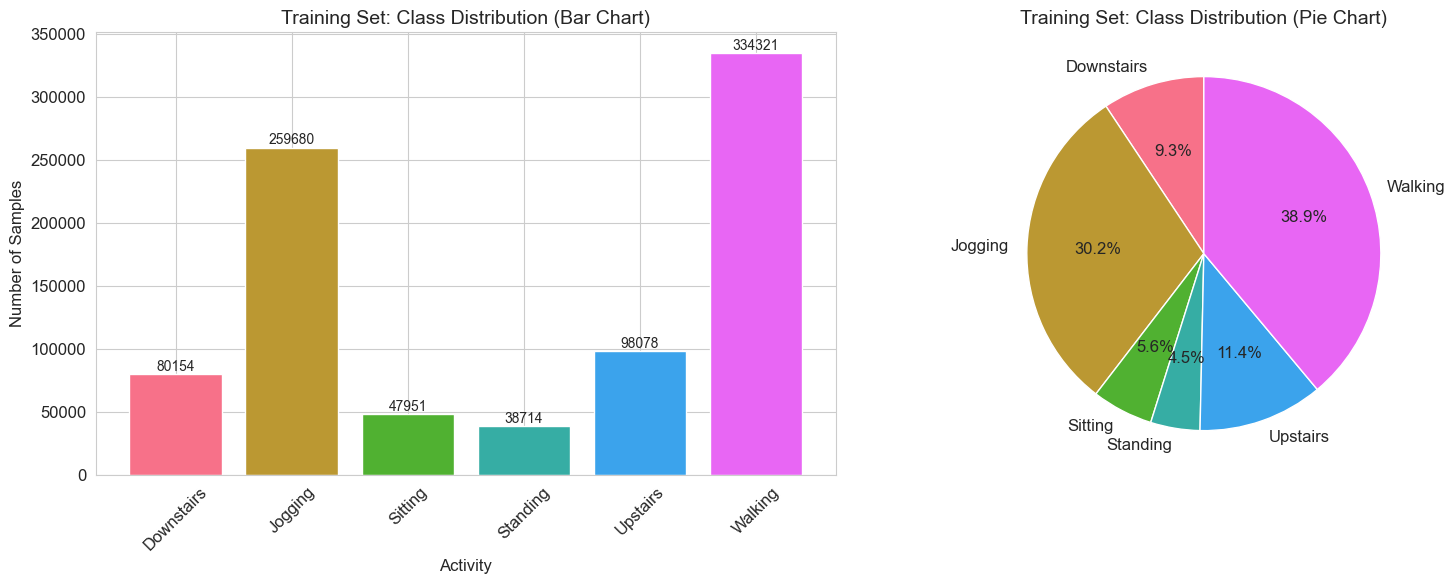

In [10]:
# Bar chart and pie chart of class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
class_counts = pd.Series(y_train).value_counts().sort_index()
colors = sns.color_palette('husl', n_colors=len(class_names))
bars = axes[0].bar(
    [class_names[i] for i in class_counts.index],
    class_counts.values,
    color=colors
)
axes[0].set_title('Training Set: Class Distribution (Bar Chart)', fontsize=14)
axes[0].set_xlabel('Activity', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 20,
                 str(count), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=[class_names[i] for i in class_counts.index],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Training Set: Class Distribution (Pie Chart)', fontsize=14)

plt.tight_layout()
plt.show()

### 2.2 Compute Imbalance Ratio

The imbalance ratio is defined as the number of samples in the largest class
divided by the number in the smallest class. Higher values indicate greater imbalance.

In [11]:
# Compute imbalance ratio
majority_count = class_counts.max()
minority_count = class_counts.min()
imbalance_ratio = majority_count / minority_count

majority_class = class_names[class_counts.idxmax()]
minority_class = class_names[class_counts.idxmin()]

print(f'Majority class: {majority_class} ({majority_count} samples)')
print(f'Minority class: {minority_class} ({minority_count} samples)')
print(f'Imbalance Ratio: {imbalance_ratio:.2f}:1')
print(f'\nThis is a {"moderate" if imbalance_ratio < 10 else "severe"} imbalance.')

Majority class: Walking (334321 samples)
Minority class: Standing (38714 samples)
Imbalance Ratio: 8.64:1

This is a moderate imbalance.


### 2.3 Apply Resampling Techniques

We compare three strategies to address class imbalance:

1. **SMOTE** (Synthetic Minority Over-sampling Technique): generates synthetic samples
   for minority classes by interpolating between nearest neighbors.
2. **RandomUnderSampler**: randomly removes samples from majority classes.
3. **SMOTETomek**: combines SMOTE oversampling with Tomek links cleaning to remove
   ambiguous borderline samples.


=== SMOTE ===
Original size: 858898 -> Resampled size: 2005926
  Downstairs  : 334321
  Jogging     : 334321
  Sitting     : 334321
  Standing    : 334321
  Upstairs    : 334321
  Walking     : 334321

=== RandomUnderSampler ===
Original size: 858898 -> Resampled size: 232284
  Downstairs  : 38714
  Jogging     : 38714
  Sitting     : 38714
  Standing    : 38714
  Upstairs    : 38714
  Walking     : 38714

=== SMOTETomek ===
Original size: 858898 -> Resampled size: 1948160
  Downstairs  : 324198
  Jogging     : 318038
  Sitting     : 334294
  Standing    : 334168
  Upstairs    : 323578
  Walking     : 313884


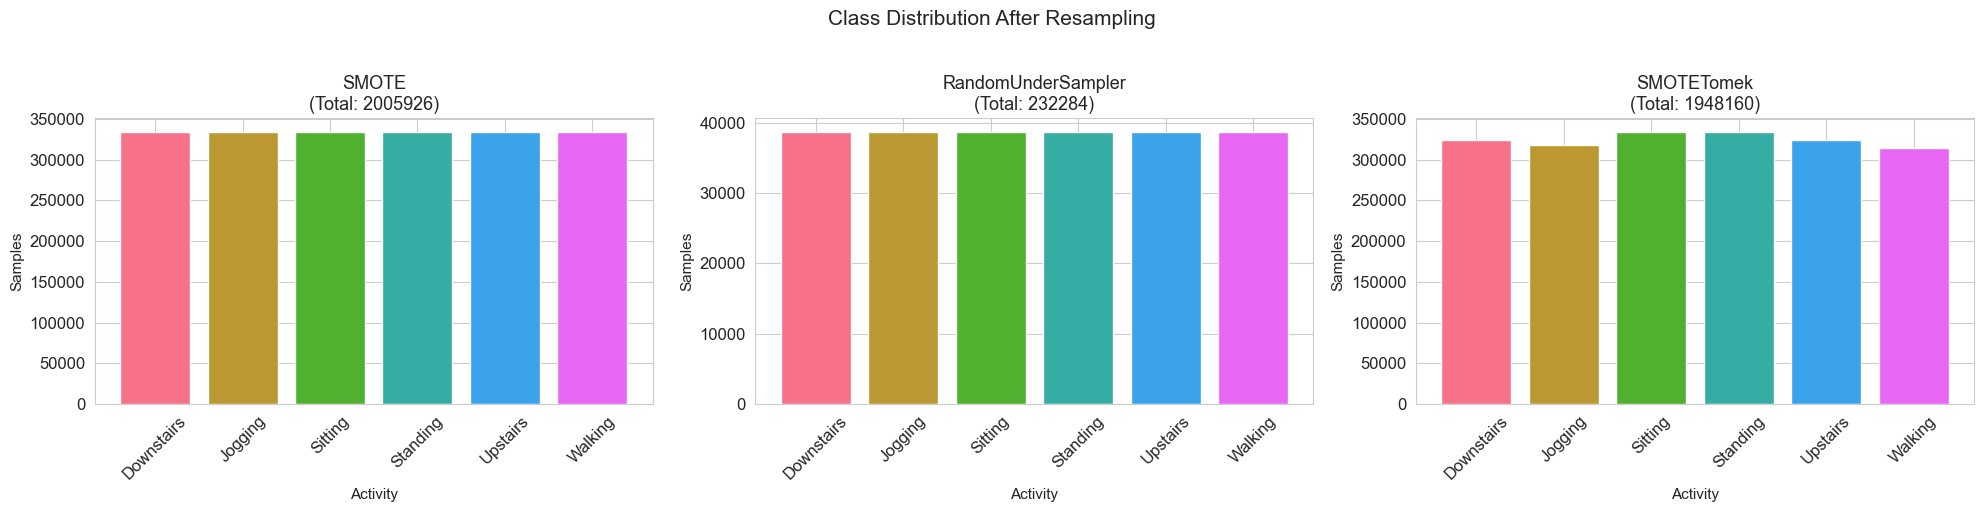

In [12]:
# Apply three resampling techniques
resampling_techniques = {
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'RandomUnderSampler': RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTETomek': SMOTETomek(random_state=RANDOM_STATE)
}

resampled_data = {}  # Store resampled datasets

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (name, sampler) in enumerate(resampling_techniques.items()):
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    resampled_data[name] = (X_res, y_res)
    
    # Class distribution after resampling
    res_counts = pd.Series(y_res).value_counts().sort_index()
    
    print(f'\n=== {name} ===')
    print(f'Original size: {len(y_train)} -> Resampled size: {len(y_res)}')
    for c_idx, count in res_counts.items():
        print(f'  {class_names[c_idx]:12s}: {count:5d}')
    
    # Bar chart
    axes[idx].bar(
        [class_names[i] for i in res_counts.index],
        res_counts.values,
        color=colors
    )
    axes[idx].set_title(f'{name}\n(Total: {len(y_res)})', fontsize=13)
    axes[idx].set_xlabel('Activity', fontsize=11)
    axes[idx].set_ylabel('Samples', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Class Distribution After Resampling', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 2.4 Compare Resampling Techniques (Empirical Evaluation)

We evaluate each resampling technique by training a **RandomForestClassifier** (fast and
robust) on each resampled dataset and measuring **F1-macro** on the held-out test set.
We also include a **No Resampling** baseline to quantify the actual benefit of resampling.

This data-driven comparison ensures we select the technique that truly performs best
on this specific dataset, rather than relying on theoretical assumptions.

Evaluating resampling techniques on test set (RandomForest, n=100)...

Technique                 |  Samples |  F1-macro |  Accuracy | Precision |    Recall
-------------------------------------------------------------------------------------
No Resampling             |   858898 |    0.9892 |    0.9922 |    0.9895 |    0.9889
SMOTE                     |  2005926 |    0.9612 |    0.9739 |    0.9611 |    0.9613
RandomUnderSampler        |   232284 |    0.9699 |    0.9723 |    0.9690 |    0.9710
SMOTETomek                |  1948160 |    0.9604 |    0.9727 |    0.9603 |    0.9606

  BEST RESAMPLING TECHNIQUE: No Resampling (F1-macro = 0.9892)


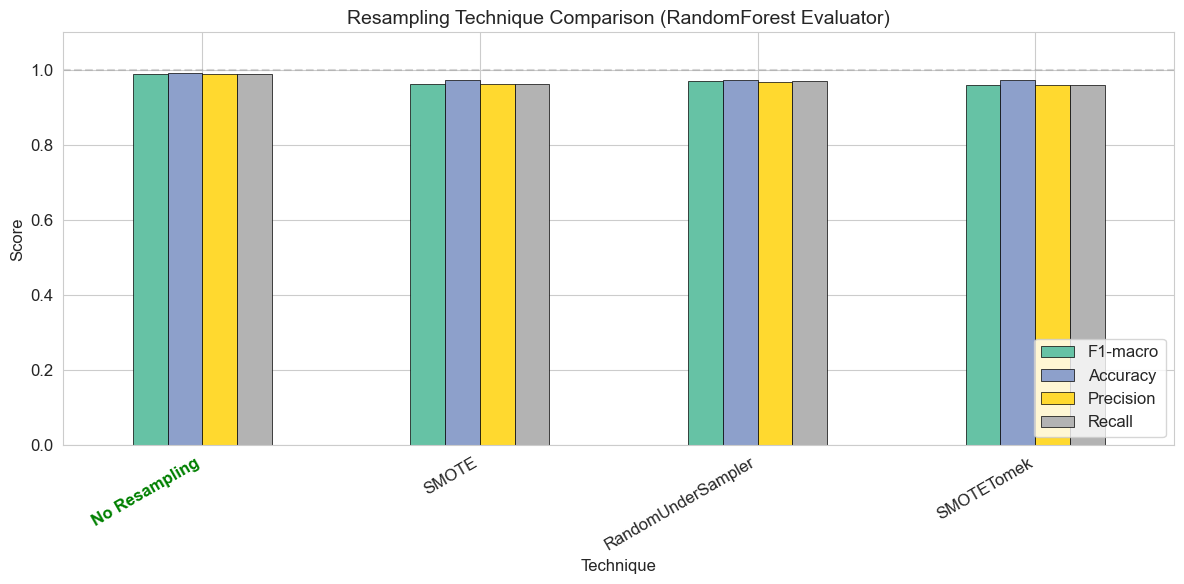


Using "No Resampling" for all subsequent model training.
Training set size: 858898 samples
Test set size (unchanged): 214725 samples


In [13]:
# Compare resampling techniques using RandomForest as a fast, reliable estimator
from sklearn.ensemble import RandomForestClassifier as _RF

comparison_results = {}

# Include "No Resampling" baseline
candidates = {
    'No Resampling': (X_train, y_train),
    **resampled_data  # SMOTE, RandomUnderSampler, SMOTETomek
}

print('Evaluating resampling techniques on test set (RandomForest, n=100)...\n')
print(f'{"Technique":<25s} | {"Samples":>8s} | {"F1-macro":>9s} | {"Accuracy":>9s} | {"Precision":>9s} | {"Recall":>9s}')
print('-' * 85)

for name, (X_res, y_res) in candidates.items():
    rf = _RF(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X_res, y_res)
    y_pred = rf.predict(X_test)
    
    f1 = f1_score(y_test, y_pred, average='macro')
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    
    comparison_results[name] = {
        'F1-macro': f1, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec,
        'n_samples': len(y_res)
    }
    
    print(f'{name:<25s} | {len(y_res):>8d} | {f1:>9.4f} | {acc:>9.4f} | {prec:>9.4f} | {rec:>9.4f}')

# Select best technique by F1-macro
best_technique = max(comparison_results, key=lambda k: comparison_results[k]['F1-macro'])
best_f1_resampling = comparison_results[best_technique]['F1-macro']

print(f'\n{"=" * 85}')
print(f'  BEST RESAMPLING TECHNIQUE: {best_technique} (F1-macro = {best_f1_resampling:.4f})')
print(f'{"=" * 85}')

# Visualization: grouped bar chart
comp_df = pd.DataFrame(comparison_results).T.drop(columns='n_samples')
fig, ax = plt.subplots(figsize=(12, 6))
comp_df.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_title('Resampling Technique Comparison (RandomForest Evaluator)', fontsize=14)
ax.set_xlabel('Technique', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(comp_df.index, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Highlight best technique bar
best_idx = list(comp_df.index).index(best_technique)
ax.get_xticklabels()[best_idx].set_fontweight('bold')
ax.get_xticklabels()[best_idx].set_color('green')

plt.tight_layout()
plt.show()

# Set the winning resampled data for all subsequent model training
if best_technique == 'No Resampling':
    X_train_resampled, y_train_resampled = X_train, y_train
else:
    X_train_resampled, y_train_resampled = resampled_data[best_technique]

print(f'\nUsing "{best_technique}" for all subsequent model training.')
print(f'Training set size: {X_train_resampled.shape[0]} samples')
print(f'Test set size (unchanged): {X_test.shape[0]} samples')

---
# Section 3: Model Comparison and Hyperparameter Tuning

We train baseline models, ensemble models, and then use Optuna for hyperparameter
tuning on the top candidates.

### 3.1 Define Baseline Models

We start with three standard classifiers as baselines:
- Logistic Regression
- K-Nearest Neighbors
- Decision Tree

In [14]:
# Define baseline models
baseline_models = {
    'LogisticRegression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, multi_class='multinomial',
        n_jobs=-1, verbose=1
    ),
    'KNeighborsClassifier': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'DecisionTreeClassifier': DecisionTreeClassifier(
        random_state=RANDOM_STATE
    )
}

print('Baseline models defined:')
for name in baseline_models:
    print(f'  - {name}')
print('\nNote: KNN and DecisionTree have no iterative progress (single-pass algorithms).')

Baseline models defined:
  - LogisticRegression
  - KNeighborsClassifier
  - DecisionTreeClassifier

Note: KNN and DecisionTree have no iterative progress (single-pass algorithms).


### 3.2 Define Ensemble Models

We define four ensemble classifiers:
- BaggingClassifier (parallel bootstrap aggregation)
- RandomForestClassifier (bagging + random feature subsets)
- AdaBoostClassifier (sequential boosting with weighted samples)
- GradientBoostingClassifier (sequential boosting with gradient descent)

In [15]:
# Define ensemble models
ensemble_models = {
    'BaggingClassifier': BaggingClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    ),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    ),
    'AdaBoostClassifier': AdaBoostClassifier(
        n_estimators=100, random_state=RANDOM_STATE, algorithm='SAMME'
    ),
    'GradientBoostingClassifier': GradientBoostingClassifier(
        n_estimators=100, random_state=RANDOM_STATE, verbose=1
    )
}

print('Ensemble models defined:')
for name in ensemble_models:
    print(f'  - {name}')
print('\nNote: AdaBoost does not support verbose progress.')

Ensemble models defined:
  - BaggingClassifier
  - RandomForestClassifier
  - AdaBoostClassifier
  - GradientBoostingClassifier

Note: AdaBoost does not support verbose progress.


### 3.3 Train and Evaluate All Baseline and Ensemble Models

We train each model on the resampled training set and evaluate on the held-out test set.
We collect metrics to compare later.

In [16]:
import time

# Combine all models
all_models = {**baseline_models, **ensemble_models}

# Store results
results = {}
trained_models = {}

total_models = len(all_models)
print(f'Training all models using: "{best_technique}" (n={len(y_train_resampled)} samples)')
print(f'{"=" * 90}\n')

for i, (name, model) in enumerate(all_models.items(), 1):
    print(f'[{i}/{total_models}] Training {name}...', end=' ', flush=True)
    
    # Train with timing
    t0 = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    train_time = time.time() - t0
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'Precision (macro)': prec,
        'Recall (macro)': rec,
        'F1 (macro)': f1,
        'MCC': mcc,
        'predictions': y_pred,
        'train_time': train_time
    }
    trained_models[name] = model
    
    # Format time nicely
    if train_time < 60:
        time_str = f'{train_time:.1f}s'
    else:
        time_str = f'{train_time/60:.1f}min'
    
    print(f'done in {time_str} | Acc: {acc:.4f} | F1: {f1:.4f} | MCC: {mcc:.4f}')

print(f'\n{"=" * 90}')
total_time = sum(r['train_time'] for r in results.values())
if total_time < 60:
    print(f'All {total_models} models trained in {total_time:.1f}s')
else:
    print(f'All {total_models} models trained in {total_time/60:.1f}min')

Training all models using: "No Resampling" (n=858898 samples)

[1/7] Training LogisticRegression... 

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.


done in 3.5s | Acc: 0.4757 | F1: 0.2565 | MCC: 0.2197
[2/7] Training KNeighborsClassifier... done in 0.3s | Acc: 0.7698 | F1: 0.7572 | MCC: 0.6823
[3/7] Training DecisionTreeClassifier... done in 3.2s | Acc: 0.9946 | F1: 0.9938 | MCC: 0.9926
[4/7] Training BaggingClassifier... 

[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:   34.4s remaining:  2.3min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:   38.1s finished
[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.3s remaining:    1.4s


done in 38.2s | Acc: 0.9967 | F1: 0.9960 | MCC: 0.9955
[5/7] Training RandomForestClassifier... 

[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.7s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   20.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    0.2s


done in 20.1s | Acc: 0.9922 | F1: 0.9892 | MCC: 0.9893
[6/7] Training AdaBoostClassifier... 

[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:    0.5s finished


done in 31.1s | Acc: 0.5144 | F1: 0.2805 | MCC: 0.2804
[7/7] Training GradientBoostingClassifier...       Iter       Train Loss   Remaining Time 
         1           1.3926            7.08m
         2           1.3355            7.00m
         3           1.2898            7.10m
         4           1.2561            7.01m
         5           1.2238            6.92m
         6           1.1978            6.85m
         7           1.1728            6.77m
         8           1.1525            6.70m
         9           1.1318            6.64m
        10           1.1152            6.57m
        20           0.9694            5.82m
        30           0.8773            5.09m
        40           0.8130            4.36m
        50           0.7599            3.62m
        60           0.7025            2.90m
        70           0.6572            2.17m
        80           0.6122            1.45m
        90           0.5752           43.38s
       100           0.5442            0.00s

### 3.4 Hyperparameter Tuning with Optuna

We use Optuna with `MedianPruner` for efficient hyperparameter search.
We tune **RandomForestClassifier**, which offers the best balance between
performance and training speed (parallelizable via `n_jobs=-1`).

GradientBoosting is excluded from tuning because its sequential nature
makes cross-validated hyperparameter search prohibitively slow on large datasets
(~858K samples). Its default configuration is already included in the baseline comparison.

- 30 trials
- StratifiedKFold with cv=5
- Optimize F1-macro score

#### 3.4.1 Optuna: RandomForestClassifier

We tune `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`,
and `max_features` for the Random Forest.

In [17]:
# Optuna objective for RandomForest
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': RANDOM_STATE
    }
    
    model = RandomForestClassifier(**params)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        model, X_train_resampled, y_train_resampled,
        cv=skf, scoring='f1_macro', n_jobs=-1
    )
    return scores.mean()

# Run optimization
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_rf = optuna.create_study(
    direction='maximize',
    pruner=MedianPruner(),
    study_name='RandomForest_Tuning'
)
study_rf.optimize(objective_rf, n_trials=30, show_progress_bar=True)

print(f'\nBest RandomForest F1-macro: {study_rf.best_value:.4f}')
print(f'Best params: {study_rf.best_params}')

Best trial: 9. Best value: 0.99507: 100%|██████████| 30/30 [1:59:28<00:00, 238.95s/it]


Best RandomForest F1-macro: 0.9951
Best params: {'n_estimators': 51, 'max_depth': 29, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None}


### 3.5 Train Tuned Model and Add to Results

We retrain the RandomForest with its best hyperparameters
and evaluate on the test set.

In [18]:
# Train tuned RF with best params
tuned_models = {
    'RF_Tuned': RandomForestClassifier(
        **study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1
    )
}

print('Training tuned model...\n')
for name, model in tuned_models.items():
    t0 = time.time()
    model.fit(X_train_resampled, y_train_resampled)
    train_time = time.time() - t0
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro')
    rec = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    mcc = matthews_corrcoef(y_test, y_pred)
    
    time_str = f'{train_time:.1f}s' if train_time < 60 else f'{train_time/60:.1f}min'
    
    results[name] = {
        'Accuracy': acc,
        'Precision (macro)': prec,
        'Recall (macro)': rec,
        'F1 (macro)': f1,
        'MCC': mcc,
        'predictions': y_pred,
        'train_time': train_time
    }
    
    print(f'{name:30s} | {time_str:>8s} | Acc: {acc:.4f} | F1-macro: {f1:.4f} | MCC: {mcc:.4f}')

Training tuned model...

RF_Tuned                       |    18.1s | Acc: 0.9967 | F1-macro: 0.9960 | MCC: 0.9955


### 3.6 VotingClassifier

We create a VotingClassifier combining the tuned RandomForest with the
baseline GradientBoosting using hard voting (majority rule).

In [19]:
# Build VotingClassifier: tuned RF + baseline GB
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(**study_rf.best_params, random_state=RANDOM_STATE, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE))
    ],
    voting='hard',
    n_jobs=-1
)

# Train and evaluate
t0 = time.time()
voting_clf.fit(X_train_resampled, y_train_resampled)
train_time = time.time() - t0
trained_models['VotingClassifier'] = voting_clf

y_pred_voting = voting_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred_voting)
prec = precision_score(y_test, y_pred_voting, average='macro')
rec = recall_score(y_test, y_pred_voting, average='macro')
f1 = f1_score(y_test, y_pred_voting, average='macro')
mcc = matthews_corrcoef(y_test, y_pred_voting)

time_str = f'{train_time:.1f}s' if train_time < 60 else f'{train_time/60:.1f}min'

results['VotingClassifier'] = {
    'Accuracy': acc,
    'Precision (macro)': prec,
    'Recall (macro)': rec,
    'F1 (macro)': f1,
    'MCC': mcc,
    'predictions': y_pred_voting,
    'train_time': train_time
}

print(f'VotingClassifier | {time_str} | Acc: {acc:.4f} | F1-macro: {f1:.4f} | MCC: {mcc:.4f}')

VotingClassifier | 7.3min | Acc: 0.9504 | F1-macro: 0.9515 | MCC: 0.9337


---
# Section 4: Results Discussion

In this section we present detailed evaluation for every model, including confusion
matrices, classification reports, and a comprehensive comparison.

### 4.1 Confusion Matrix Heatmaps

For each model we display the confusion matrix as a heatmap.

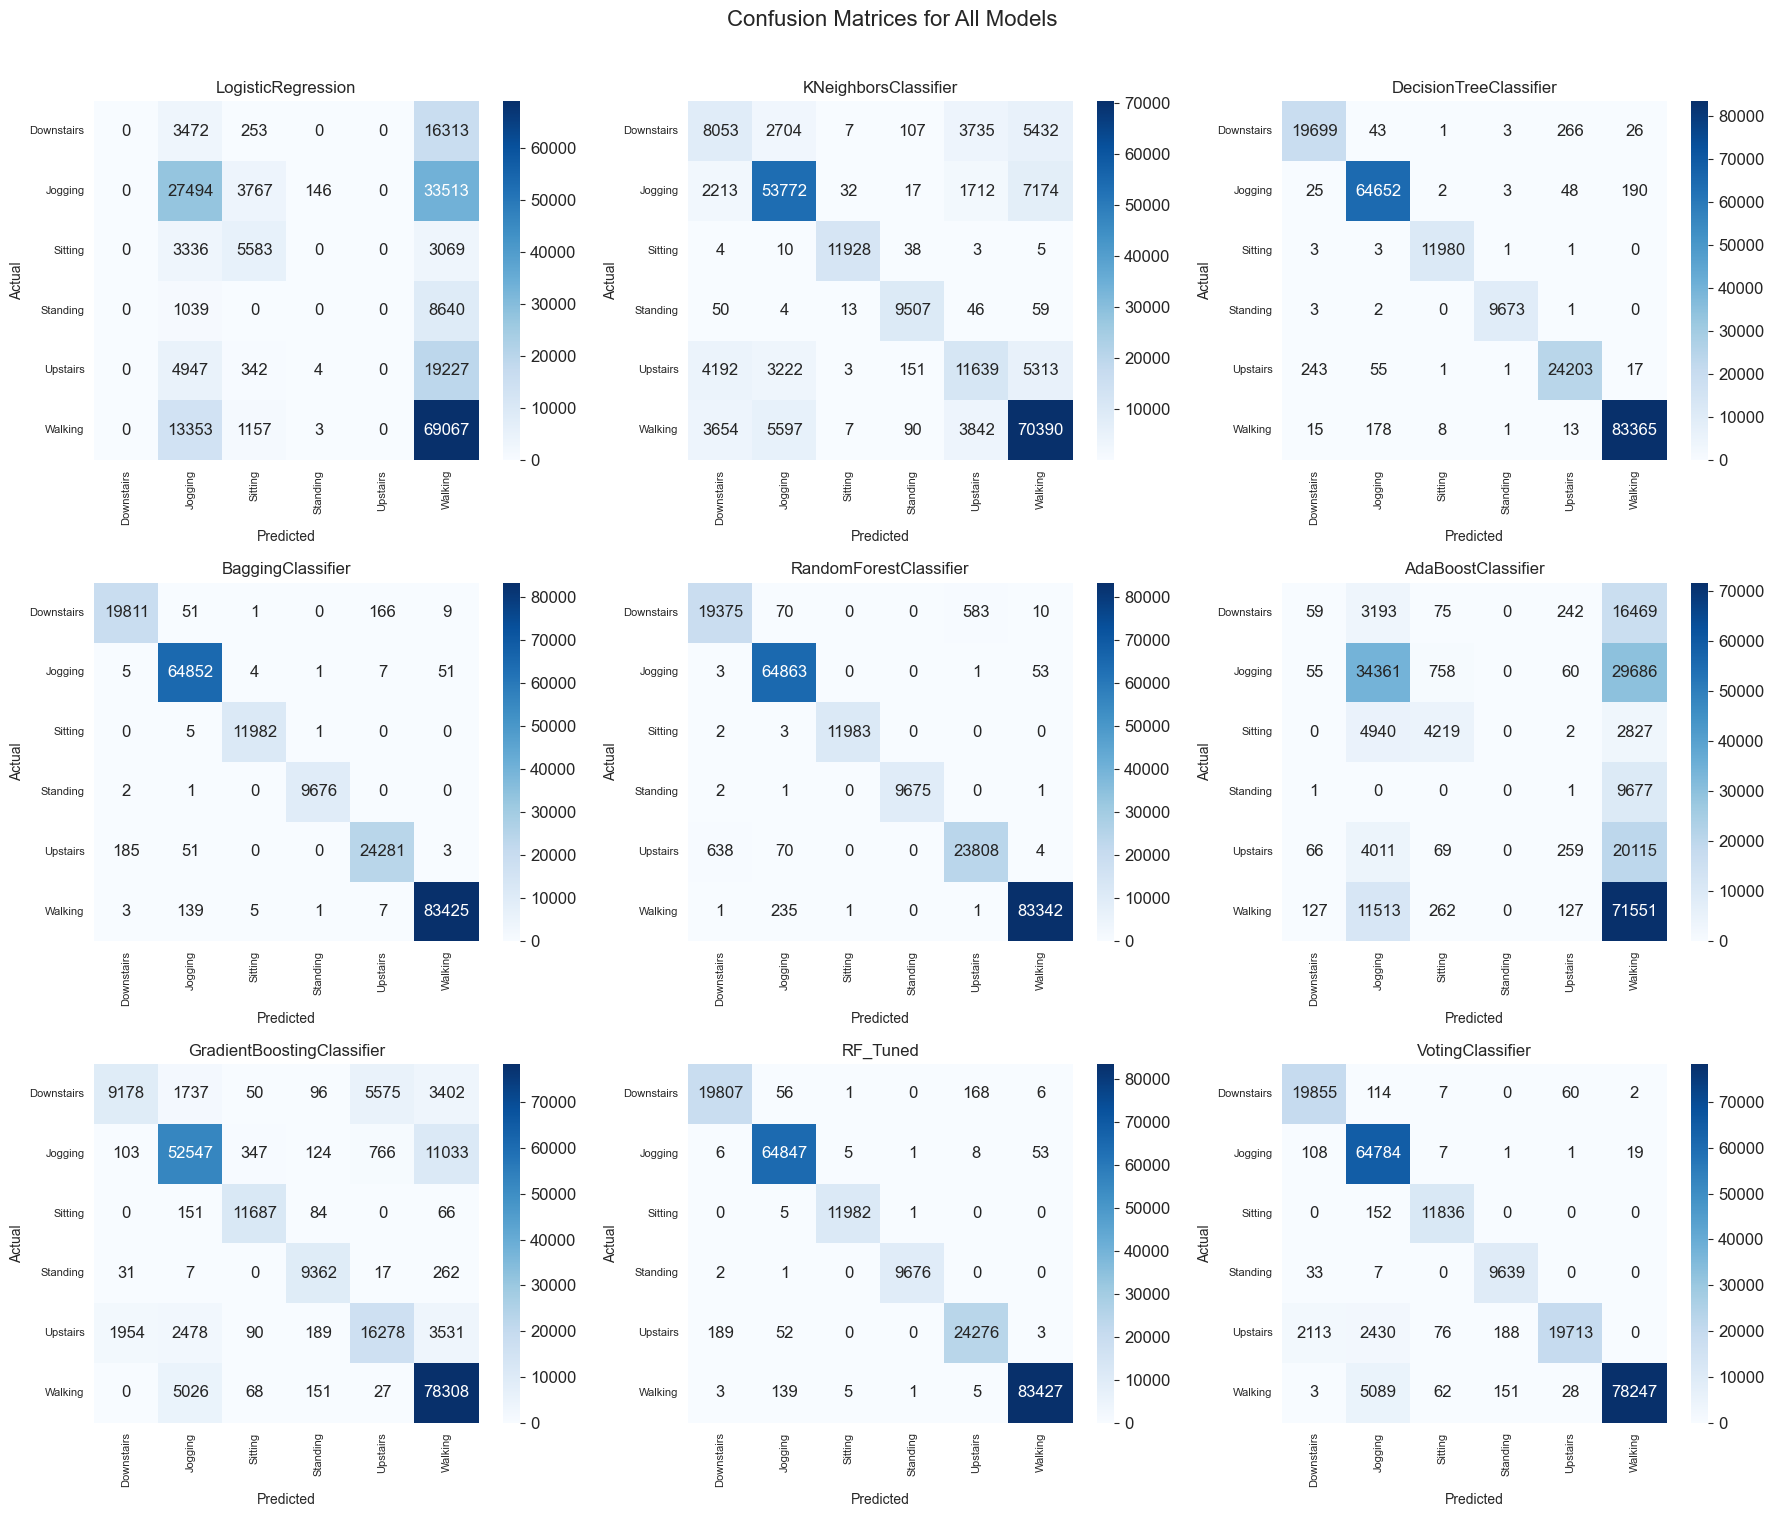

In [20]:
# Generate confusion matrices for all models
model_names_list = list(results.keys())
n_models = len(model_names_list)

n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = axes.flatten()

for idx, model_name in enumerate(model_names_list):
    y_pred = results[model_name]['predictions']
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[idx]
    )
    axes[idx].set_title(f'{model_name}', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)
    axes[idx].tick_params(axis='both', labelsize=8)

for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Confusion Matrices for All Models', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Classification Reports

Detailed per-class metrics (precision, recall, F1) for every model.

In [21]:
# Print classification reports for all models
for model_name in model_names_list:
    y_pred = results[model_name]['predictions']
    print(f'\n{"=" * 60}')
    print(f'Classification Report: {model_name}')
    print(f'{"=" * 60}')
    print(classification_report(
        y_test, y_pred,
        target_names=class_names,
        digits=4
    ))


Classification Report: LogisticRegression
              precision    recall  f1-score   support

  Downstairs     0.0000    0.0000    0.0000     20038
     Jogging     0.5126    0.4235    0.4638     64920
     Sitting     0.5029    0.4657    0.4836     11988
    Standing     0.0000    0.0000    0.0000      9679
    Upstairs     0.0000    0.0000    0.0000     24520
     Walking     0.4610    0.8264    0.5918     83580

    accuracy                         0.4757    214725
   macro avg     0.2461    0.2859    0.2565    214725
weighted avg     0.3625    0.4757    0.3976    214725


Classification Report: KNeighborsClassifier
              precision    recall  f1-score   support

  Downstairs     0.4433    0.4019    0.4216     20038
     Jogging     0.8233    0.8283    0.8258     64920
     Sitting     0.9948    0.9950    0.9949     11988
    Standing     0.9593    0.9822    0.9706      9679
    Upstairs     0.5548    0.4747    0.5116     24520
     Walking     0.7965    0.8422    0.8187 

### 4.3 Summary DataFrame

We create a summary table comparing all models across all metrics,
sorted by F1-macro score in descending order.

In [22]:
# Build summary DataFrame
summary_data = []
for model_name in model_names_list:
    row = {
        'Model': model_name,
        'Accuracy': results[model_name]['Accuracy'],
        'Precision (macro)': results[model_name]['Precision (macro)'],
        'Recall (macro)': results[model_name]['Recall (macro)'],
        'F1 (macro)': results[model_name]['F1 (macro)'],
        'MCC': results[model_name]['MCC']
    }
    summary_data.append(row)

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('F1 (macro)', ascending=False).reset_index(drop=True)

print('=== Model Comparison (sorted by F1-macro) ===')
display(summary_df.style.highlight_max(
    subset=['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'MCC'],
    color='lightgreen'
).format({
    'Accuracy': '{:.4f}',
    'Precision (macro)': '{:.4f}',
    'Recall (macro)': '{:.4f}',
    'F1 (macro)': '{:.4f}',
    'MCC': '{:.4f}'
}))

=== Model Comparison (sorted by F1-macro) ===


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),MCC
0,BaggingClassifier,0.9967,0.9962,0.9959,0.9960,0.9955
1,RF_Tuned,0.9967,0.9961,0.9958,0.9960,0.9955
2,DecisionTreeClassifier,0.9946,0.9938,0.9937,0.9938,0.9926
3,RandomForestClassifier,0.9922,0.9895,0.9889,0.9892,0.9893
4,VotingClassifier,0.9504,0.9565,0.9520,0.9515,0.9337
5,GradientBoostingClassifier,0.8260,0.8470,0.8017,0.8150,0.7600
6,KNeighborsClassifier,0.7698,0.7620,0.7540,0.7572,0.6823
7,AdaBoostClassifier,0.5144,0.4031,0.2918,0.2805,0.2804
8,LogisticRegression,0.4757,0.2461,0.2859,0.2565,0.2197


### 4.4 Grouped Bar Chart: Model Comparison

A visual comparison of all models across the key evaluation metrics.

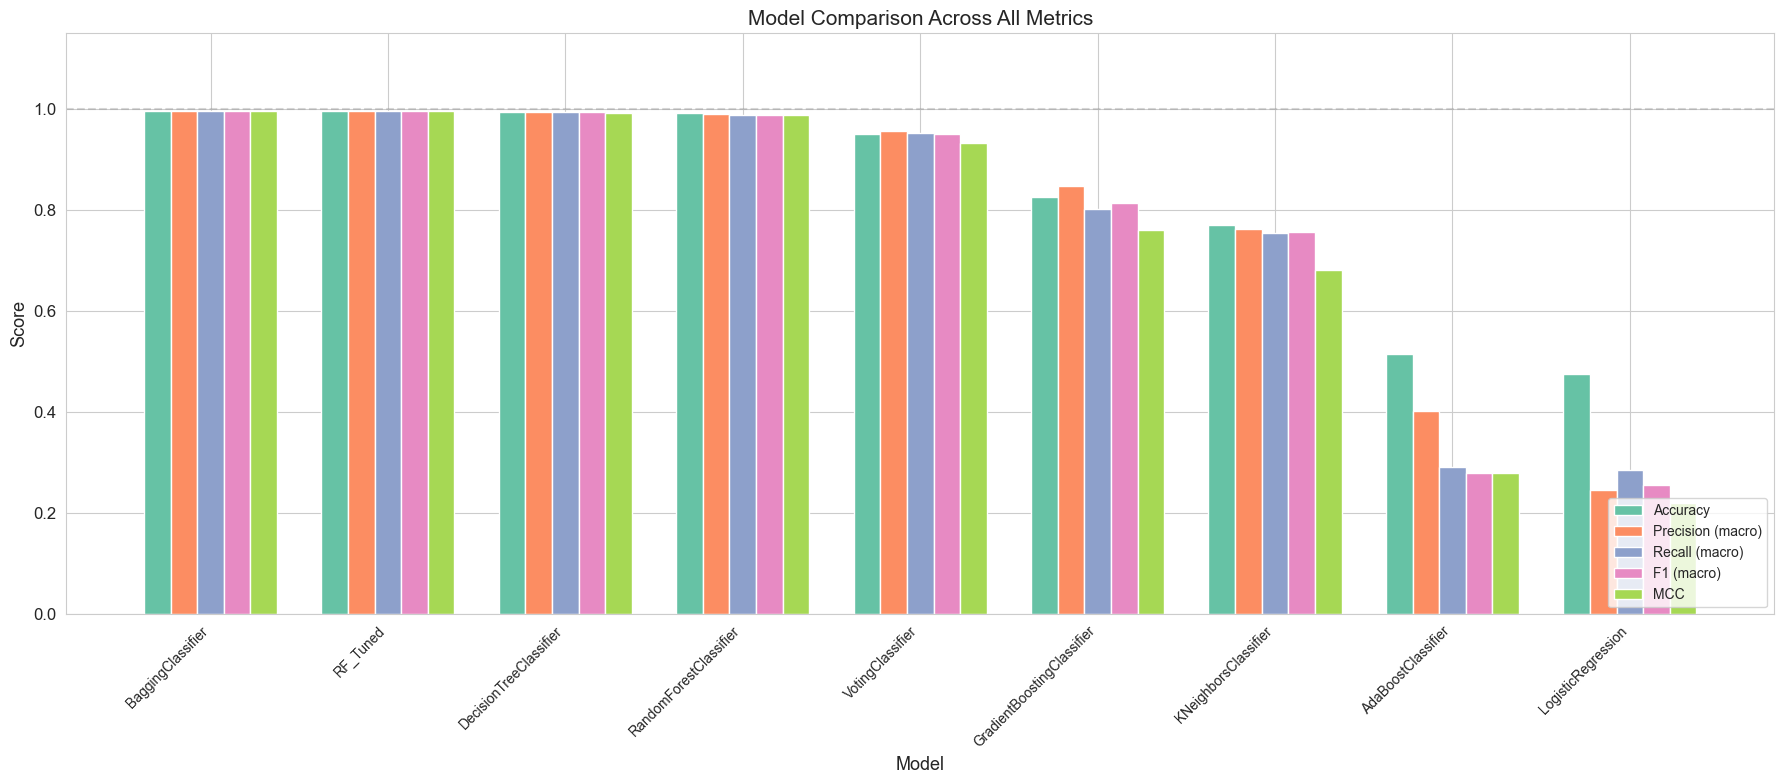

In [23]:
# Grouped bar chart comparing all models
metrics_to_plot = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)', 'MCC']
plot_df = summary_df.set_index('Model')[metrics_to_plot]

fig, ax = plt.subplots(figsize=(18, 8))
x = np.arange(len(plot_df))
width = 0.15
multiplier = 0

color_palette = sns.color_palette('Set2', len(metrics_to_plot))

for i, metric in enumerate(metrics_to_plot):
    offset = width * multiplier
    bars = ax.bar(x + offset, plot_df[metric], width, label=metric, color=color_palette[i])
    multiplier += 1

ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Model Comparison Across All Metrics', fontsize=15)
ax.set_xticks(x + width * 2)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right', fontsize=10)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5 Best Model Identification

We identify the best-performing model and explain why it excels.

  BEST MODEL: BaggingClassifier
  Accuracy:      0.9967
  F1-macro:      0.9960
  MCC:           0.9955

Analysis:
The BaggingClassifier achieved the highest F1-macro score of 0.9960.
F1-macro is the primary metric because it accounts for both precision and recall
across all classes equally, which is critical in an imbalanced multi-class setting.
The MCC (Matthews Correlation Coefficient) further confirms the result, as it
provides a balanced measure even when classes are of very different sizes.

=== Confusion Matrix: BaggingClassifier ===


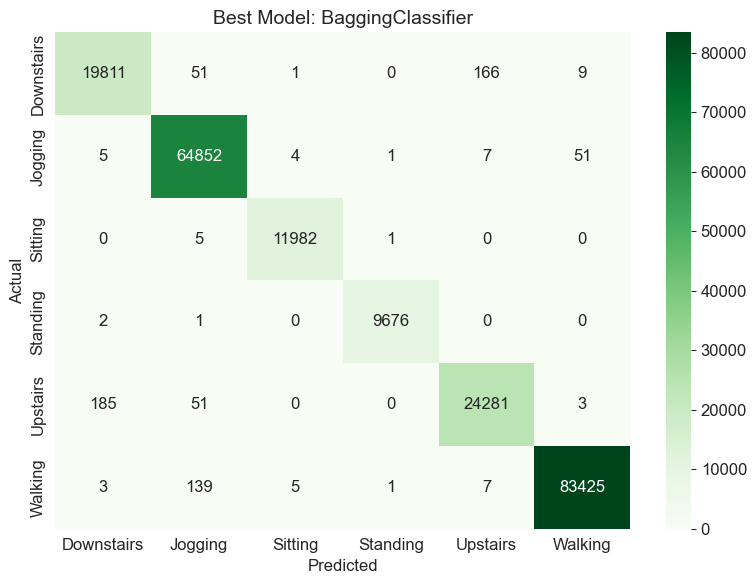


=== Full Classification Report: BaggingClassifier ===
              precision    recall  f1-score   support

  Downstairs     0.9903    0.9887    0.9895     20038
     Jogging     0.9962    0.9990    0.9976     64920
     Sitting     0.9992    0.9995    0.9993     11988
    Standing     0.9997    0.9997    0.9997      9679
    Upstairs     0.9926    0.9903    0.9914     24520
     Walking     0.9992    0.9981    0.9987     83580

    accuracy                         0.9967    214725
   macro avg     0.9962    0.9959    0.9960    214725
weighted avg     0.9967    0.9967    0.9967    214725



In [24]:
# Identify the best model
best_model_name = summary_df.iloc[0]['Model']
best_f1 = summary_df.iloc[0]['F1 (macro)']
best_acc = summary_df.iloc[0]['Accuracy']
best_mcc = summary_df.iloc[0]['MCC']

print(f'==========================================')
print(f'  BEST MODEL: {best_model_name}')
print(f'==========================================')
print(f'  Accuracy:      {best_acc:.4f}')
print(f'  F1-macro:      {best_f1:.4f}')
print(f'  MCC:           {best_mcc:.4f}')
print(f'==========================================')
print()
print('Analysis:')
print(f'The {best_model_name} achieved the highest F1-macro score of {best_f1:.4f}.')
print('F1-macro is the primary metric because it accounts for both precision and recall')
print('across all classes equally, which is critical in an imbalanced multi-class setting.')
print('The MCC (Matthews Correlation Coefficient) further confirms the result, as it')
print('provides a balanced measure even when classes are of very different sizes.')

# Show confusion matrix for best model
print(f'\n=== Confusion Matrix: {best_model_name} ===')
y_pred_best = results[best_model_name]['predictions']
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm_best, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_names, yticklabels=class_names, ax=ax
)
ax.set_title(f'Best Model: {best_model_name}', fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\n=== Full Classification Report: {best_model_name} ===')
print(classification_report(y_test, y_pred_best, target_names=class_names, digits=4))